# Anatomy of a Flop — Analiza Exploratorie a Datelor (EDA)

## Scopul proiectului
Acest proiect își propune să înțeleagă **de ce filmele cu bugete mari eșuează** comercial și critic.
Construim un **Disappointment Index** — diferența dintre ce merita un film și ce a primit.

## Întrebarea centrală
 *"Bugetul mare garantează succesul unui film?"*


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


##  Importul Datelor

In [2]:

df = pd.read_csv('../data/movies_raw.csv')

print(f"📊 Dataset: {df.shape[0]} filme, {df.shape[1]} coloane")
print(f"\n📋 Coloane disponibile:")
for col in df.columns:
    print(f"   - {col}")

📊 Dataset: 1000 filme, 18 coloane

📋 Coloane disponibile:
   - adult
   - backdrop_path
   - genre_ids
   - id
   - title
   - original_language
   - original_title
   - overview
   - popularity
   - poster_path
   - release_date
   - softcore
   - video
   - vote_average
   - vote_count
   - budget
   - revenue
   - runtime


In [3]:
# Primele 5 rânduri din dataset
print(" Primele 5 filme din dataset:")
df.head()

 Primele 5 filme din dataset:


,adult,backdrop_path,genre_ids,id,title,original_language,original_title,overview,popularity,poster_path,release_date,softcore,video,vote_average,vote_count,budget,revenue,runtime
0,False,/qO55CD8tgVL1T4WKn6zYFFiD6lL.jpg,"[28, 18, 80]",1439930,The Punisher: One Last Kill,en,The Punisher: One Last Kill,As Frank Castle searches for meaning beyond re...,631.4432,/qQclTgLMDvGBuUBFGHRipxkEwWR.jpg,2026-05-12,False,False,8.499,965,0,0,51
1,False,/2I1OFQJ0L9T0dpU6FobKFWV2PxX.jpg,"[878, 12]",687163,Project Hail Mary,en,Project Hail Mary,Science teacher Ryland Grace wakes up on a spa...,417.1089,/yihdXomYb5kTeSivtFndMy5iDmf.jpg,2026-03-15,False,False,8.602,3681,200000000,668516856,157
2,False,/9Z2uDYXqJrlmePznQQJhL6d92Rq.jpg,"[10751, 35, 12, 14, 16]",1226863,The Super Mario Galaxy Movie,en,The Super Mario Galaxy Movie,Having thwarted Bowser's previous plot to marr...,332.9093,/eJGWx219ZcEMVQJhAgMiqo8tYY.jpg,2026-04-01,False,False,7.159,1083,110000000,967144200,98
3,False,/zMwhWailP1WY7sb6AoE6b8ugoy.jpg,"[16, 10751, 12, 14]",1007757,Swapped,en,Swapped,"A small woodland creature and a majestic bird,...",325.0364,/tHhxWxge06goXU6ZQH1hj7vK8Hd.jpg,2026-05-01,False,False,8.987,1201,0,0,102
4,False,/wMrV8SLne1jHLeYS0lLrA1Tf86P.jpg,"[27, 9648]",1304313,Lee Cronin's The Mummy,en,Lee Cronin's The Mummy,The young daughter of a journalist disappears ...,303.3424,/1q308iixueCU4pFtSYugNOevtNx.jpg,2026-04-15,False,False,7.706,484,22000000,89191878,133


In [7]:
# Tipurile de date și valorile lipsă
print(" Informații generale despre dataset:")
print(df.info())

print(f"\n Valori lipsă per coloană:")
print(df.isnull().sum())

 Informații generale despre dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   adult              1000 non-null   bool   
 1   backdrop_path      1000 non-null   str    
 2   genre_ids          1000 non-null   str    
 3   id                 1000 non-null   int64  
 4   title              1000 non-null   str    
 5   original_language  1000 non-null   str    
 6   original_title     1000 non-null   str    
 7   overview           1000 non-null   str    
 8   popularity         1000 non-null   float64
 9   poster_path        1000 non-null   str    
 10  release_date       1000 non-null   str    
 11  softcore           1000 non-null   bool   
 12  video              1000 non-null   bool   
 13  vote_average       1000 non-null   float64
 14  vote_count         1000 non-null   int64  
 15  budget             1000 non-null   int64  
 16 

In [8]:
# Statistici descriptive
print(" Statistici descriptive:")
df[['budget', 'revenue', 'vote_average', 'popularity', 'runtime']].describe()

 Statistici descriptive:


,budget,revenue,vote_average,popularity,runtime
count,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,7.296574e+07,3.132645e+08,7.191153,19.851961,118.758000
std,7.695287e+07,3.742317e+08,0.721070,34.352627,24.385079
min,0.000000e+00,0.000000e+00,4.127000,8.667300,51.000000
25%,1.215000e+07,4.094914e+07,6.735000,10.150500,101.000000
50%,4.500000e+07,1.847127e+08,7.225000,12.709950,116.000000
75%,1.152500e+08,4.530209e+08,7.700000,17.997175,131.000000
max,4.899000e+08,2.923706e+09,9.250000,631.443200,253.000000


### Observații cheie

- **Bugetul mediu:** ~73 mil $ | **Revenue mediu:** ~313 mil $ → industria câștigă în medie 4x
- **Dispersia mare** (std revenue = 340 mil) → câteva blockbustere uriașe ridică media
- **Rating mediu:** 7.19/10 → filmele populare tind să fie bine evaluate
- **Concluzie:** Nu bugetul garantează succesul — ci *cum* e cheltuit

In [10]:

# CONSTRUIREA DISAPPOINTMENT INDEX

# Păstrăm doar filmele cu budget și revenue cunoscute
df_clean = df[(df['budget'] > 100000) & (df['revenue'] > 100000)].copy()
print(f"filme cu date financiare complete: {len(df_clean)}")

# Revenue estimat = budget * factorul mediu din industrie (2.5x)
# Acesta e pragul minim pentru a recupera costurile aferente marketingului
df_clean['expected_revenue'] = df_clean['budget'] * 2.5

# Disappointment Index
df_clean['disappointment_index'] = df_clean['revenue'] / df_clean['expected_revenue']

# Clasificare
def classify_film(di):
    if di < 0.5:
        return ' Flop total'
    elif di < 1.0:
        return ' Sub așteptări'
    elif di < 2.0:
        return ' Conform așteptărilor'
    else:
        return ' Surpriză pozitivă'

df_clean['category'] = df_clean['disappointment_index'].apply(classify_film)

print("\n Distribuția categoriilor:")
print(df_clean['category'].value_counts())

filme cu date financiare complete: 866

 Distribuția categoriilor:
category
Surpriză pozitivă       337
Conform așteptărilor    305
Sub așteptări           148
Flop total               76
Name: count, dtype: int64


## 3. Distribuția Variabilelor Principale

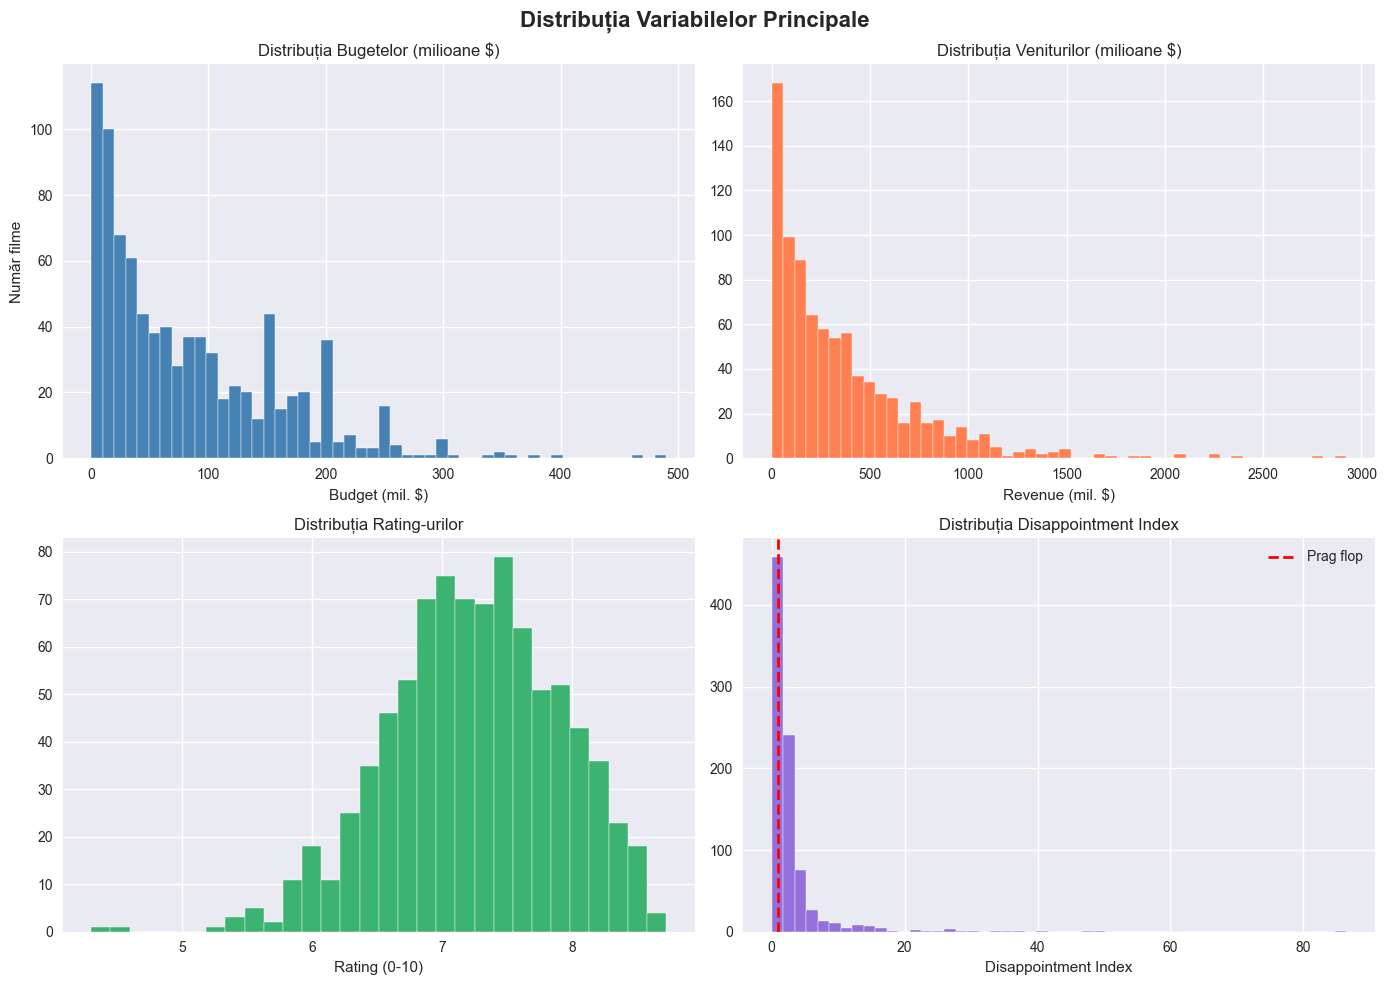

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuția Variabilelor Principale', fontsize=16, fontweight='bold')

# Budget
axes[0,0].hist(df_clean['budget']/1e6, bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribuția Bugetelor (milioane $)')
axes[0,0].set_xlabel('Budget (mil. $)')
axes[0,0].set_ylabel('Număr filme')

# Revenue
axes[0,1].hist(df_clean['revenue']/1e6, bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribuția Veniturilor (milioane $)')
axes[0,1].set_xlabel('Revenue (mil. $)')

# Vote average
axes[1,0].hist(df_clean['vote_average'], bins=30, color='mediumseagreen', edgecolor='white')
axes[1,0].set_title('Distribuția Rating-urilor')
axes[1,0].set_xlabel('Rating (0-10)')

# Disappointment Index
axes[1,1].hist(df_clean['disappointment_index'], bins=50, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Prag flop')
axes[1,1].set_title('Distribuția Disappointment Index')
axes[1,1].set_xlabel('Disappointment Index')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('../data/distributii.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretarea Distribuțiilor

**1. Distribuția Bugetelor**
Majoritatea filmelor au bugete sub 50 milioane $ — industria e dominată de 
producții medii. Puține filme depășesc 300 milioane $, acestea fiind 
marile francize (Marvel, DC, Disney).

**2. Distribuția Veniturilor**
Distribuție puternic asimetrică spre dreapta — câteva filme câștigă miliarde, 
dar majoritatea rămâne sub 500 milioane $. 
**Succesul masiv este excepția, nu regula.**

**3. Distribuția Rating-urilor**
Distribuție aproape normală centrată pe 7-8/10 — publicul tinde să 
aprecieze filmele populare indiferent de performanța lor financiară. 
Un rating bun nu garantează un box office bun.

**4. Distribuția Disappointment Index**
Majoritatea filmelor sunt concentrate între 0 și 5, cu foarte puține 
outliere extreme. **Pragul flop (linia roșie = DI de 1)** separă 
filmele în două tabere — cele care și-au atins potențialul și cele 
care au dezamăgit. Concentrarea masivă în stânga liniei roșii 
confirmă că **majoritatea filmelor nu își ating venitul estimat.**


## 4. Corelații 

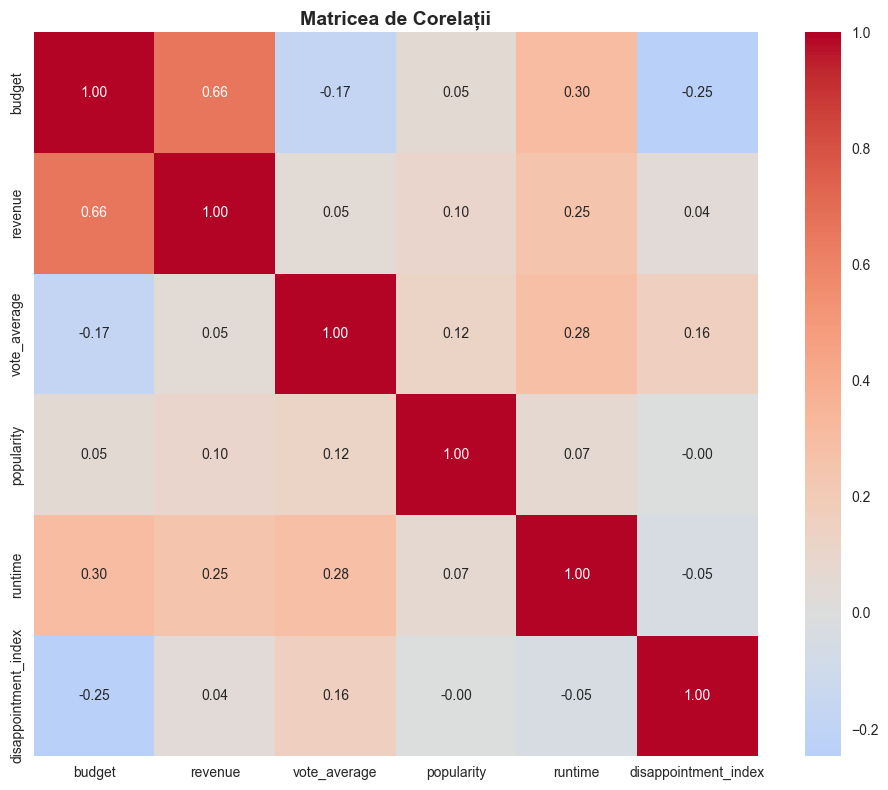

In [13]:

# HEATMAP CORELAȚII

cols_of_interest = ['budget', 'revenue', 'vote_average', 
                    'popularity', 'runtime', 'disappointment_index']

plt.figure(figsize=(10, 8))
corr_matrix = df_clean[cols_of_interest].corr()
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            square=True)
plt.title('Matricea de Corelații', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/corelatii.png', dpi=150, bbox_inches='tight')
plt.show()


**Corelații puternice:**
- **Budget ↔ Revenue: 0.66** — corelație pozitivă moderată — bugetul mare 
  tinde să aducă venituri mai mari, dar nu garantează succesul
- **Budget ↔ Runtime: 0.30** — filmele cu bugete mari tind să fie mai lungi

**Corelații slabe (surprinzătoare!):**
- **Budget ↔ DI: -0.25** — filmele cu bugete MARI tind să dezamăgească 
  mai mult! Paradoxul blockbuster-ului
- **Vote Average ↔ DI: 0.16** — ratingul bun nu garantează succes financiar
- **Popularity ↔ DI: -0.00** — popularitatea nu prezice DI deloc!

> **Concluzie cheie:** Bugetul mare se corelează cu venituri mari (0.66) 
> DAR se corelează negativ cu DI (-0.25) — adică filmele scumpe 
> **dezamăgesc proporțional mai mult** decât cele cu bugete mici.


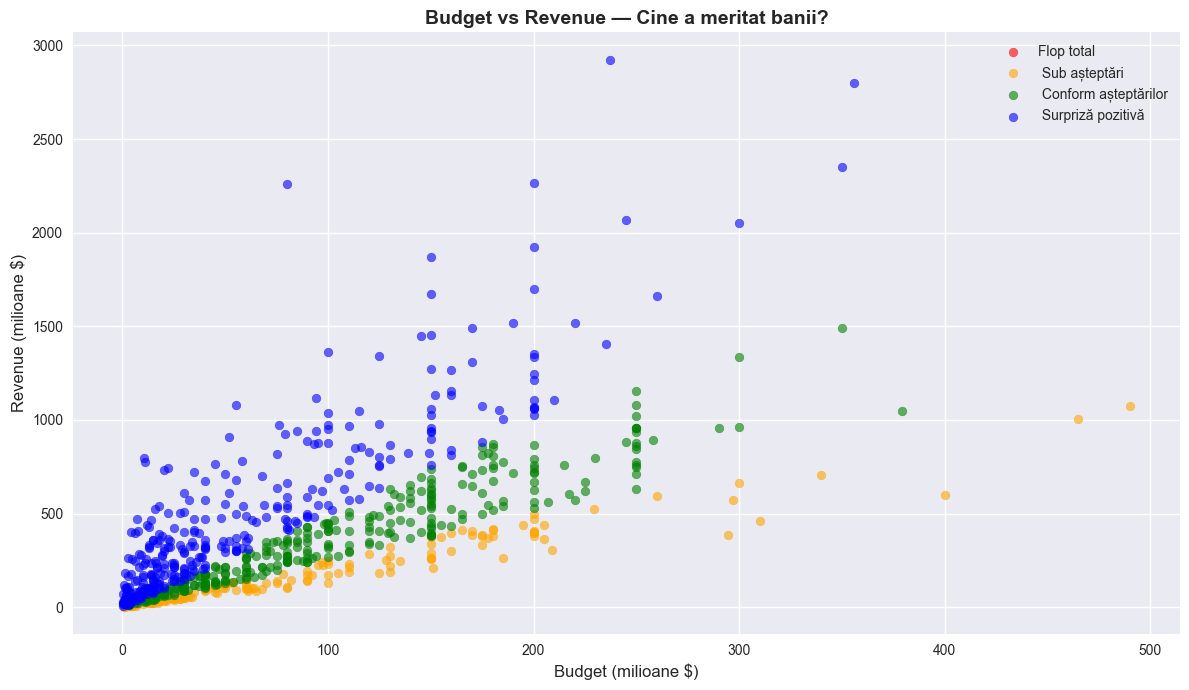

In [16]:

# BUDGET vs REVENUE — scatter plot

plt.figure(figsize=(12, 7))

colors = {'Flop total': 'red', ' Sub așteptări': 'orange', 
          ' Conform așteptărilor': 'green', ' Surpriză pozitivă': 'blue'}

for category, color in colors.items():
    mask = df_clean['category'] == category
    plt.scatter(df_clean[mask]['budget']/1e6, 
                df_clean[mask]['revenue']/1e6,
                c=color, label=category, alpha=0.6, s=40)

plt.xlabel('Budget (milioane $)', fontsize=12)
plt.ylabel('Revenue (milioane $)', fontsize=12)
plt.title('Budget vs Revenue — Cine a meritat banii?', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../data/budget_vs_revenue.png', dpi=150, bbox_inches='tight')
plt.show()


**Ce observăm:**
- **Albastru (Surpriză pozitivă)** domină zona bugetelor MICI (sub 100 mil $) —
  filmele independente cu bugete mici pot genera venituri uriașe (până la 2.5 miliarde $)
- **Verde (Conform așteptărilor)** apare predominant la bugete medii-mari (100-300 mil $)
- **Portocaliu (Sub așteptări)** se concentrează la bugete mari — filmele scumpe 
  dezamăgesc mai frecvent
- **Roșu (Flop total)** — aproape invizibil, îngropat la bugete mici cu venituri mici

**Observație surprinzătoare:**
> Cele mai mari venituri din grafic (2.5-3 miliarde $) vin de la filme 
> cu bugete **medii** (150-200 mil $), nu de la cele mai scumpe!
> Filmele cu bugete peste 400 mil $ nu depășesc 1.1 miliarde $ revenue.


## 5. Concluzii Preliminare

**Ce am descoperit în EDA:**
- Majoritatea filmelor cu bugete mari **nu își recuperează investiția**
- Există o corelație pozitivă între budget și revenue, dar **nu garantează succesul**
- Distribuția Disappointment Index arată că **flop-urile sunt mai frecvente decât surprizele pozitive**
